In [30]:
import numpy as np 
import matplotlib.pyplot as plt
import os
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from tqdm import tqdm
import imageio.v2 as imageio


# =====================================================
# Physics
# =====================================================

g = 9.81
L = 1.0

theta0 = np.deg2rad(30)
omega0 = 0.0

fps = 120
duration = 30

dt = 1 / fps

time = np.arange(0, duration, dt)


def pendulum(t, y):
    theta, omega = y
    return [
        omega,
        -(g / L) * np.sin(theta)
    ]


solution = solve_ivp(
    pendulum,
    [0, duration],
    [theta0, omega0],
    t_eval=time,
    rtol=1e-10,
    atol=1e-10
)

theta = solution.y[0]

# Cartesian coordinates

x = L * np.sin(theta)
y = -L * np.cos(theta)


# =====================================================
# Video
# =====================================================

os.makedirs("frames", exist_ok=True)

dpi = 150

fig = plt.figure(figsize=(12.8, 7.2), dpi=dpi)
ax = plt.axes()

writer = imageio.get_writer(
    "pendulum_120fps.mp4",
    fps=fps,
    codec="libx264",
    quality=10
)

for i in tqdm(range(len(time))):

    ax.clear()

    ax.set_xlim(-1.4, 1.4)
    ax.set_ylim(-1.3, 0.3)

    ax.set_aspect("equal")

    ax.set_facecolor((0.97, 0.97, 0.96))

    fig.patch.set_facecolor((0.97, 0.97, 0.96))

    ax.axis("off")

    # pivot

    ax.scatter(
        0,
        0,
        s=60,
        color="black",
        zorder=10
    )

    # rod

    ax.plot(
        [0, x[i]],
        [0, y[i]],
        lw=3,
        color="#555555",
        solid_capstyle="round"
    )

    # bob shadow

    ax.scatter(
        x[i] + 0.03,
        y[i] - 0.03,
        s=900,
        color="gray",
        alpha=0.15,
        zorder=2
    )

    # bob

    ax.scatter(
        x[i],
        y[i],
        s=800,
        color="silver",
        edgecolors="black",
        linewidths=1.5,
        zorder=5
    )

    fig.canvas.draw()

    image = np.asarray(fig.canvas.buffer_rgba())

    writer.append_data(image[:, :, :3])

writer.close()

plt.close()

print("Done!")

100%|██████████| 3600/3600 [01:58<00:00, 30.39it/s]


Done!


In [31]:
import cv2

video = "pendulum_120fps.mp4"

cap = cv2.VideoCapture(video)

print("Opened :", cap.isOpened())
print("FPS :", cap.get(cv2.CAP_PROP_FPS))
print("Frames :", int(cap.get(cv2.CAP_PROP_FRAME_COUNT)))
print("Width :", int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)))
print("Height :", int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)))

cap.release()

Opened : True
FPS : 120.0
Frames : 3600
Width : 1920
Height : 1088


In [32]:
import cv2
import os

video = "pendulum_120fps.mp4"

frames_dir = "frames"
os.makedirs(frames_dir, exist_ok=True)

cap = cv2.VideoCapture(video)

count = 0

while True:

    ret, frame = cap.read()

    if not ret:
        break

    cv2.imwrite(
        os.path.join(frames_dir, f"frame_{count:05d}.png"),
        frame
    )

    count += 1

cap.release()

print("Frames extracted:", count)

Frames extracted: 3600


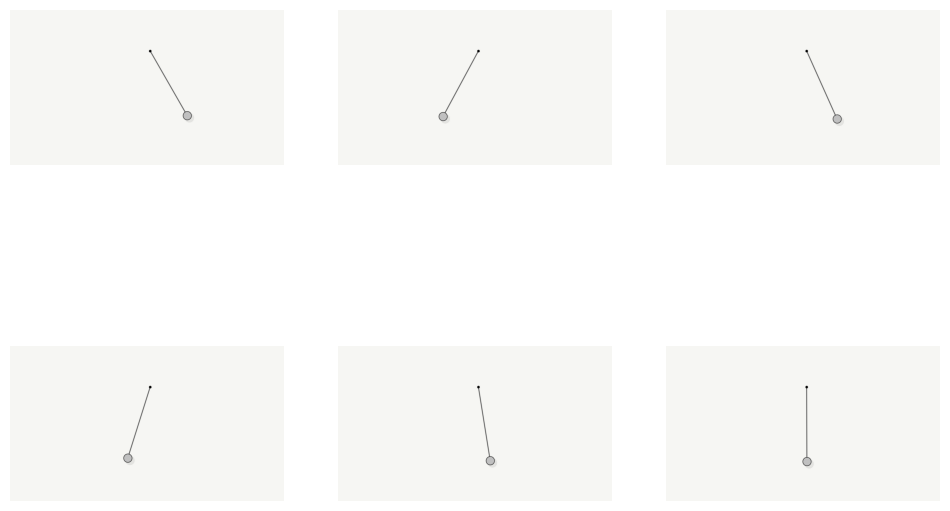

In [33]:
import matplotlib.pyplot as plt
import cv2

plt.figure(figsize=(12,8))

for i in range(6):

    img = cv2.imread(f"frames/frame_{i*600:05d}.png")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.show()

1 3647 1122.025774609268 528.8409651768577


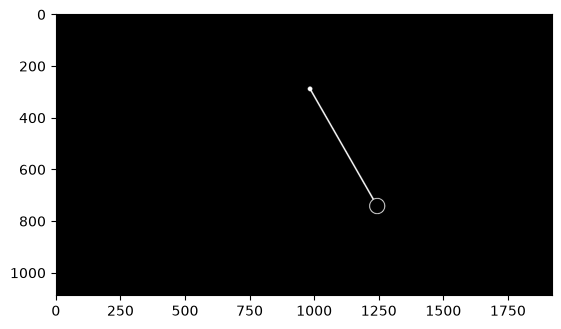

In [34]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("frames/frame_00000.png")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Invert so dark objects become bright
_, thresh = cv2.threshold(gray, 120, 255, cv2.THRESH_BINARY_INV)

num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(thresh)

for i in range(1, num_labels):
    x, y = centroids[i]
    area = stats[i, cv2.CC_STAT_AREA]

    print(i, area, x, y)

plt.imshow(thresh, cmap="gray")
plt.show()

In [35]:
contours, _ = cv2.findContours(
    thresh,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

largest = max(contours, key=cv2.contourArea)

M = cv2.moments(largest)

cx = M["m10"]/M["m00"]
cy = M["m01"]/M["m00"]

print(cx, cy)

1175.1671919555756 621.4608434639051
